<a href="https://colab.research.google.com/github/spicy-adobo/LIS-4-5693/blob/main/lab-7/lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sentiment Analysis Lab

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [17]:
import requests
import io

url = "https://raw.githubusercontent.com/spicy-adobo/LIS-4-5693/refs/heads/main/lab-7/imdb_review%20(1).csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text))
df.insert(0, 'id', range(1, len(df) + 1))
print(df.head())

   id  review_id  split label  review_rating  \
0   1       4856   test   pos              8   
1   2       8777  train   pos             10   
2   3      12379  train   pos              8   
3   4       6893  train   pos             10   
4   5       8971   test   neg              4   

                                         review_text  review_length  
0  Others' main criticism of this film--namely th...            192  
1  Errol Flynn's greatest movie, not just a sport...             44  
2  I was an usherette in an old theater in Northe...            129  
3  Gerard Phillipe is absolutely perfect in this ...             55  
4  This feels very stilted and patronizing to a g...             96  


New dataframe with id and review text field, non-alphabet removed and converted to lowercase

In [19]:
df_subset = df[['id', 'review_text']].copy()

In [20]:
df_subset['review_text'] = df_subset['review_text'].str.replace("[^a-zA-Z#]", "   ")


In [21]:
df_subset['review_text'] = df_subset['review_text'].str.casefold()
print(df_subset.head(10))

   id                                        review_text
0   1  others' main criticism of this film--namely th...
1   2  errol flynn's greatest movie, not just a sport...
2   3  i was an usherette in an old theater in northe...
3   4  gerard phillipe is absolutely perfect in this ...
4   5  this feels very stilted and patronizing to a g...
5   6  i love movies in this genre. beautiful girls, ...
6   7  this animation has a very simple and straightf...
7   8  terrible terrible movie for television. once a...
8   9  very well done and spooky horror movie from po...
9  10  this is one of the great modern kung fu films....


Generating Sentiment Polarity Scores

In [22]:
df1 = pd.DataFrame()
df1['id'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [24]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['review_text']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'id': row['id'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
    id sentiment_type  sentiment_score
3    1       compound          -0.8765
7    2       compound           0.8291
11   3       compound           0.2240
15   4       compound           0.9743
19   5       compound           0.9348
23   6       compound           0.6087
27   7       compound           0.9763
31   8       compound          -0.9524
35   9       compound          -0.2128
39  10       compound           0.9919


In [25]:
df_output = pd.merge(df, t_df_cleaned, on='id', how='inner')
print(df_output.head(10))

   id  review_id  split label  review_rating  \
0   1       4856   test   pos              8   
1   2       8777  train   pos             10   
2   3      12379  train   pos              8   
3   4       6893  train   pos             10   
4   5       8971   test   neg              4   
5   6       4385   test   neg              2   
6   7       7340  train   pos              8   
7   8       7776   test   neg              1   
8   9       5543  train   pos              7   
9  10      11887   test   pos              8   

                                         review_text  review_length  \
0  Others' main criticism of this film--namely th...            192   
1  Errol Flynn's greatest movie, not just a sport...             44   
2  I was an usherette in an old theater in Northe...            129   
3  Gerard Phillipe is absolutely perfect in this ...             55   
4  This feels very stilted and patronizing to a g...             96   
5  I love movies in this genre. Beautiful gir

#Task 1
The text field for my data will be the review_text column that contains the actual movie reviews. I merged the id column with the sentiment scores to have a cleaner set. The describe method is utlized in the next code cell. Followed then by the two different visualizations.

Visualizing Sentiment Analysis Output

In [26]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,18000.000000
mean,0.295024
std,0.808092
min,-0.999700
25%,-0.699100
50%,0.818250
75%,0.970100
max,0.999900


<Axes: title={'center': 'Distribution of Sentiment Scores'}, ylabel='Frequency'>

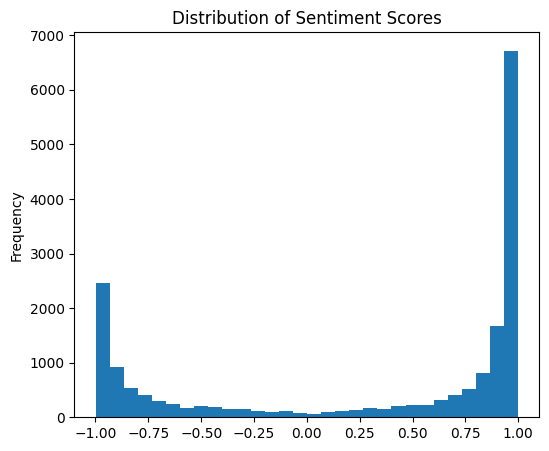

In [31]:
df_output['sentiment_score'].plot(
    kind='hist',
    bins=30,
    title='Distribution of Sentiment Scores',
    figsize=(6,5)
)

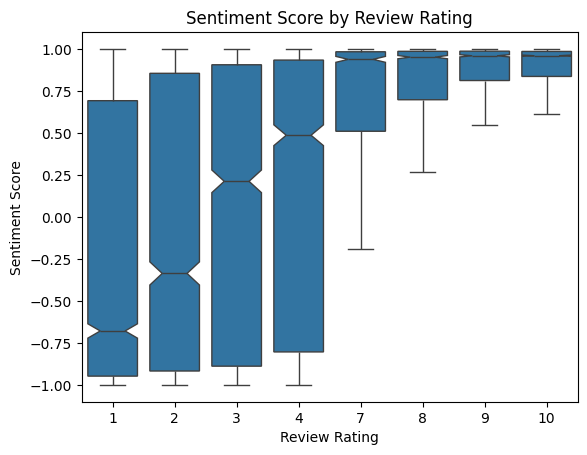

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# create seaborn boxplot by review_rating
sns.boxplot(x='review_rating',
            y='sentiment_score',
            notch=True,
            data=df_output,
            showfliers=False).set(title='Sentiment Score by Review Rating')

# modify axis labels
plt.xlabel('Review Rating')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=0)

plt.show()

#Task 2
I struggled a lot with getting the dataset set up since I missed the initial assignment using the dataset. I felt lost as initially I only really had the reviews and the scores and was unaware of what my next steps needed to be. Granted, I'm sure the previous lab helps set us up for success. However, it felt like one of those moments where the brief seems easier than the actual thing you need to do since my data set didn't have all these columns like Year of Province to work with, so I had to do my own work to have more than just reviews and scores to compare. Again I did struggle with trying to upload the csv to Github and being beyond the file size limit multiple times.
Sentiment analysis seems easy to apply to really any career field working with customers.